In [1]:
import pandas as pd
a=pd.read_csv(r"C:\Users\subhadip sinha\OneDrive\CODING\PYTHON\Scikit-Learn\diabetes.csv")
a

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [2]:
a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [3]:
x=a.iloc[:,:-1]
y=a.iloc[:,-1]


In [4]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)

In [8]:
from sklearn.preprocessing import PowerTransformer
pt=PowerTransformer(method="box-cox")
x_train_pt=pt.fit_transform(x_train+0.000001)
x_test_pt=pt.transform(x_test+0.000001)

In [15]:
from sklearn.linear_model import LogisticRegression
lor=LogisticRegression()
lor.fit(x_train_pt,y_train)
lor.score(x_test_pt,y_test)*100

75.32467532467533

C:\Users\subhadip sinha\AppData\Local\Temp\ipykernel_10760\3881980836.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y)


<Axes: xlabel='Outcome', ylabel='Density'>

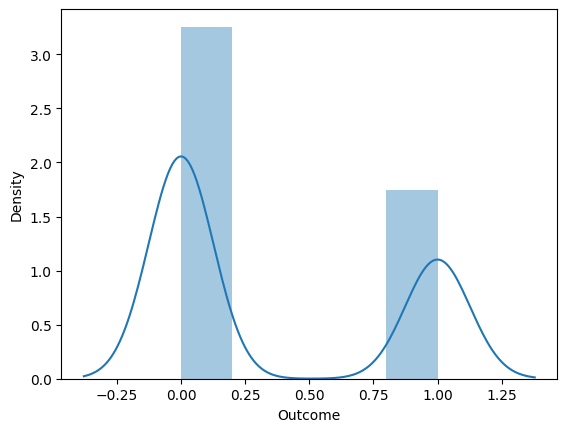

In [17]:
import seaborn as sns
sns.distplot(y)

In [18]:
y.value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64